# Assignment 3: Recurrent Neural Network (RNN) {-}

This assignment is designed to help you understand how recurrent neural networks are applied to a text classification task using the IMDB movie review dataset. You will go through the complete workflow, including loading the dataset, analyzing and preprocessing text data, building different RNN based models, and evaluating their performance. By experimenting with GRU, LSTM, and bidirectional variants, you will gain practical insight into how different RNN architectures affect classification accuracy and runtime efficiency. You will have to do:

1.  **(5 points) Coding tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Analyze and preprocess the dataset to make it suitable for training RNN based models.  
    1.2 *(1 point)* Build an RNN model using GRU (Gated Recurrent Unit, https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU) instead of LSTM, following the demo code provided. Train the model and evaluate its performance on the test set.  
    1.3 *(1 point)* Build an RNN model using Bidirectional LSTM (BiLSTM, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional). Train the model and evaluate its performance on the test set.  
    1.4 *(1 point)* Build an RNN model using Bidirectional GRU (BiGRU, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional). Train the model and evaluate its performance on the test set.  
    1.5 *(1 point)* Compare the models built in this assignment, including LSTM, GRU, BiLSTM, and BiGRU, in terms of classification accuracy and runtime efficiency. Discuss your observations and explain the performance differences among these model variants.  

2.  **(5 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    2.1 *(1 point)* During preprocessing, text is converted into sequences of integers. Discuss how the choice of vocabulary size and handling of rare words can affect both model performance and generalization on unseen reviews.  
    2.2 *(1 point)* Bidirectional RNNs process sequences in both forward and backward directions. Discuss how this bidirectional context can improve sentiment classification and provide examples of review patterns where this might be especially helpful.  
    2.3 *(1 point)* Is the IMDB dataset class imbalanced, and how does its class distribution influence the selection of evaluation metrics? In your opinion, which evaluation metrics should be used to better understand the model’s performance, and why?  
    2.4 *(1 point)* Sequence length truncation is often applied to limit computational cost. Discuss the trade off between keeping longer sequences for richer context and truncating them for faster training and lower memory usage.  
    2.5 *(1 point)* Based on your overall findings, propose improvements or extensions to this assignment. These may include architectural changes, different preprocessing strategies, or alternative evaluation methods, and explain how they could lead to better sentiment classification performance.  


The dataset you will be working on is imdb_reviews. This dataset is a large movie review dataset. This dataset is for binary sentiment classification containing a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. All the reviews have either a positive or negative sentiment. Reference: http://ai.stanford.edu/~amaas/data/sentiment/

Each data sample contains:
- label (tf.int64)
- text (tf.string)

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment3-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named DL4AI-\<StudentID>-Assignment3 (e.g., DL4AI-2012345-Assigment3) and then compressed with the same name.

### Evaluation {-}
The assignment will be evaluated based on how complete and correct your implementation is, and how clear and well reasoned your answers are in the open discussion questions. In particular:
- The models must be properly trained, showing neither clear overfitting nor clear underfitting.
- Model evaluation must be done on a separate test set that is not used for training or tuning.
- Your analysis should show a clear understanding of training behavior, convergence, and generalization.

In addition, your code must follow good Python coding practices, including clear structure, readable naming, appropriate comments, and compliance with a standard coding convention such as PEP 8.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
# Note: to enable GPU training in Colab, go to Runtime > Change runtime type > Hardware acceleration > Choose GPU from the drop-down list.

# Download tensorflow datasets
!pip install tensorflow_datasets

# Import libraries
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# Load the IMDB movie review dataset, return text (movie review) and label (positive/negative)
train_dataset, val_dataset, test_dataset = tfds.load(name="imdb_reviews", split=('train[:80%]', 'train[80%:]', 'test'), as_supervised=True)

print("Training set: ", len(train_dataset), "samples")
print("Validation set: ", len(val_dataset), "samples")
print("Test set: ", len(test_dataset), "samples")



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.M9MSWV_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.M9MSWV_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.M9MSWV_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Training set:  20000 samples
Validation set:  5000 samples
Test set:  25000 samples


In [ ]:
print(train_dataset.element_spec)
# The train_dataset consists of 2 elements. The first Tensor contains text, type tf.string
# The second Tensor contains the label, 1 (positive reviews) and 0 (negative reviews) in this dataset



(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))


In [ ]:
# Show same samples in the training set
for example, label in train_dataset.take(3):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0
text:  b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. 

## 1. Coding tasks

####    1.1 Analyze and preprocess the dataset to make it suitable for training RNN based models.  
Since RNN requires the input as fixed length sequences of integers.
Each batch input must have the same length for the sake of efficient working on GPU.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow_datasets as tfds

In [ ]:
### Convert Tensorflow Dataset to numpy arrays of feature vector X and label y

# Convert training set
train_ds_numpy = tfds.as_numpy(train_dataset) # Convert TF Dataset to an iterable of numpy array
train_numpy = np.vstack(list(train_ds_numpy)) # Stack to full numpy array
 # So this scans through the dataset (consists of pairs (text,label)) and stack these pairs
  # to create a matrix N,2 with N being the number of data samples.
X_train = tf.convert_to_tensor(list(map(lambda x: x[0], train_numpy)), dtype=tf.string) # Extract review (index 0) from numpy vector
y_train = np.array(list(map(lambda x: x[1], train_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector and convert grom string to number
print("X_train shape: " + str(X_train.shape))
print("y_train shape: " + str(y_train.shape))

# Convert validation set
val_ds_numpy = tfds.as_numpy(val_dataset) # Convert TF Dataset to an iterable of numpy array
val_numpy = np.vstack(list(val_ds_numpy)) # Stack to full numpy array
X_val = tf.convert_to_tensor(list(map(lambda x: x[0], val_numpy)), dtype=tf.string) # Extract review (index 0) from numpy vector
y_val = np.array(list(map(lambda x: x[1], val_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector
print("X_val shape: " + str(X_val.shape))
print("y_val shape: " + str(y_val.shape))

# Convert test set
test_ds_numpy = tfds.as_numpy(test_dataset) # Convert TF Dataset to an iterable of numpy array
test_numpy = np.vstack(list(test_ds_numpy)) # Stack to full numpy array
X_test = tf.convert_to_tensor(list(map(lambda x: x[0], test_numpy)), dtype=tf.string) # Extract review (index 0) from numpy vector
y_test = np.array(list(map(lambda x: x[1], test_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector
print("X_test shape: " + str(X_test.shape))
print("y_test shape: " + str(y_test.shape))

X_train shape: (20000,)
y_train shape: (20000,)
X_val shape: (5000,)
y_val shape: (5000,)
X_test shape: (25000,)
y_test shape: (25000,)


In [ ]:
VOCAB_SIZE = 10000

# Initialize the TextVectorization layer for raw text encoding
text_encoder = tf.keras.layers.TextVectorization(max_tokens = VOCAB_SIZE)

# Feed training text to adapt() method to calculate the layer's vocabulary
text_encoder.adapt(X_train)

In [ ]:
# Show the first 20 tokens. After the padding ('') and unknown ([UNK]) tokens they're sorted by frequency.
vocab = np.array(text_encoder.get_vocabulary()) # Get the vocabulary of the training set after the adaptation
print("Vocabulary size:", vocab.shape)
vocab[:20] # Show the first 20 tokens (sorted by frequency) in the vocabulary

Vocabulary size: (10000,)


array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U17')

In [ ]:
# TEST THE VECTORIZATION LAYER
# model.predict to scan through all layers and return the result
model_encoder = tf.keras.models.Sequential()

model_encoder.add(tf.keras.Input(shape=(1,), dtype=tf.string))
model_encoder.add(text_encoder)

test_data = [["I want to drink"], ["I do not want to eat but I want to sleep"]]
test_data = tf.convert_to_tensor(test_data, dtype=tf.string)
model_encoder.predict(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


array([[  10,  179,    6, 3455,    0,    0,    0,    0,    0,    0,    0],
       [  10,   79,   22,  179,    6, 1987,   19,   10,  179,    6, 1733]])

#### 1.2 Build an RNN model using GRU (Gated Recurrent Unit) instead of LSTM, following the demo code provided. Train the model and evaluate its performance on the test set.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the Model
# We use a Sequential API for clarity.
# 'mask_zero=True' is crucial so the GRU ignores padding tokens (0).
gru_model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    text_encoder,
    tf.keras.layers.Embedding(
        input_dim=len(text_encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True
    ),
    # Add dropout layer after embedding to prevent model memorizing all the vocab
    tf.keras.layers.SpatialDropout1D(0.3), # SpatialDropout1D
    # GRU layer: 64 units is a good balance between capacity and speed
    tf.keras.layers.GRU(64, dropout=0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Regularization to achieve better test accuracy
    tf.keras.layers.Dense(1, activation='sigmoid')
])

gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, None, 64)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,309,185 (4.99 MB)

 Trainable params: 1,309,185 (4.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
my_callbacks = [
    # 1. EarlyStopping: Stops training when validation loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',     # Watch the validation loss
        patience=4,             # Wait 4 epochs before giving up
        restore_best_weights=True, # VERY IMPORTANT: jumps back to the best version
        verbose=1
    ),

    # 2. ReduceLROnPlateau: Lowers the learning rate if the model gets "stuck"
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,             # Cut LR by 80% (e.g., 1e-3 becomes 2e-4)
        patience=2,             # Wait 2 epochs of no improvement
        min_lr=1e-6,            # Don't let it get too small to learn
        verbose=1
    )]

In [ ]:
# Compile the model
# For binary classification (pos/neg), BinaryCrossentropy is the standard choice.
gru_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Train the model
# Use a validation split to monitor overfitting in real-time
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=my_callbacks

)

# Evaluate on the test set
test_loss, test_acc = gru_model.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {test_acc:.4f}')

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.5790 - loss: 0.6878 - val_accuracy: 0.6310 - val_loss: 0.6790 - learning_rate: 1.0000e-04
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7484 - loss: 0.5296 - val_accuracy: 0.8668 - val_loss: 0.3295 - learning_rate: 1.0000e-04
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8808 - loss: 0.3027 - val_accuracy: 0.8798 - val_loss: 0.2997 - learning_rate: 1.0000e-04
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9108 - loss: 0.2378 - val_accuracy: 0.8906 - val_loss: 0.2750 - learning_rate: 1.0000e-04
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9266 - loss: 0.2007 - val_accuracy: 0.8782 - val_loss: 0.2936 - learning_rate: 1.0000e-04
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9438 - loss: 0.1626
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - a

**Design choices**:
- SpatialDropout1D after embedding: To avoid the model remembering all vocabulary.
- mask_zero = True: Masking tells the GRU to skip the zeros (padding) in sequences.
- Dropout: The IMDB dataset is small (20k training samples). We need dropout layers to make the model learn more generalizable patterns.
- BinaryCrossentropy: Since your final layer is Dense(1, activation='sigmoid'), this is the mathematically correct loss function for binary sentiment.

In [ ]:
gru_path = '/content/drive/MyDrive/DL4AI Model/imdb_gru_model.keras'

# Save model
gru_model.save(gru_path)
print(f"Saved model at: {gru_path}")

Saved model at: /content/drive/MyDrive/DL4AI Model/imdb_gru_model.keras


In [ ]:
reconstructed_gru = tf.keras.models.load_model(gru_path)
reconstructed_gru.summary()

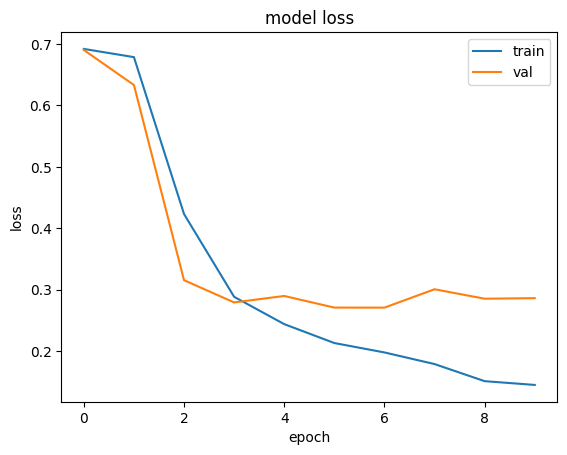

In [ ]:
# Visualize the training and validation loss over epochs
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

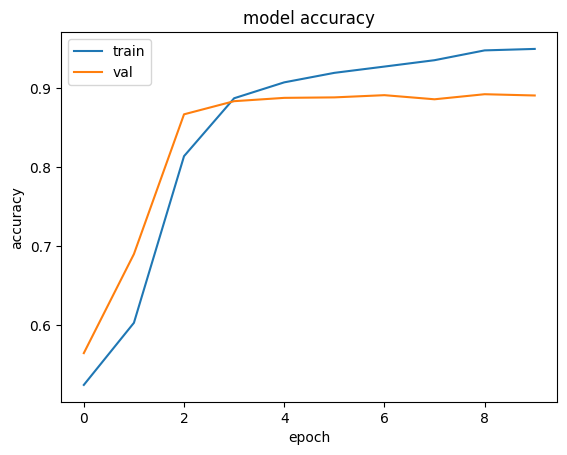

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = gru_model.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8828 - loss: 0.2872
Test Loss: 0.28717634081840515
Test Accuracy: 0.8828399777412415


In [ ]:
# Make prediction on a new data sample
sample_reviews = [('It is a cool movie. The graphics and the animation are awesome.'),
                  ('The movie was really bad. I would not recommend it to anyone.')]
sample_reviews = tf.convert_to_tensor(sample_reviews, dtype=tf.string)
predictions = gru_model.predict(sample_reviews)
print(predictions[0])
print(predictions[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
[0.851728]
[0.28240666]


**Model Performance Analysis of GRU on IMDB Dataset:**

The GRU model achieved a Test Accuracy of 88.28%, indicating strong generalization across the IMDB dataset. However, the divergence between the training loss (decreasing) and validation loss (plateauing at ~0.28) suggests that while the model is highly effective, it has reached its maximum learning capacity with the current architecture.

Manual testing confirms the model's ability to map text to the correct sentiment probability. For a review containing positive descriptors like 'awesome,' the model returned a value of 0.85, indicating a high probability of Positive sentiment. Conversely, for a review containing the phrase 'would not recommend,' the model returned a value of 0.28, correctly falling below the 0.5 threshold and thus classifying the comment as Negative. This demonstrates that the GRU layers are successfully capturing the semantic context required for sentiment distinction.

####1.3. Build Bidirectional LSTM - BiLSTM. Train and evaluate its performance on the test set.

Bidirectional LSTM is intended to understand deeper context compared to standard LSTMs or GRUs.

Standard LSTMs (and GRUs) read text like we do: left to right. However, in language, the meaning of a word often depends on words that come after it.

Standard LSTM: Reads "The movie was not..." and has to guess what comes next.

Bidirectional LSTM: Reads the sentence in both directions (Left-to-Right AND Right-to-Left) simultaneously.

It uses two separate hidden layers that are concatenated at the end. This allows the model to know that "not" is followed by "bad," instantly changing the sentiment from negative to positive.

In [ ]:
VOCAB_SIZE = 20000

# Initialize the TextVectorization layer for raw text encoding
text_encoder = tf.keras.layers.TextVectorization(max_tokens = VOCAB_SIZE)

# Feed training text to adapt() method to calculate the layer's vocabulary
text_encoder.adapt(X_train)

In [ ]:
# IMPROVED VERSION OF BILSTM
# Refined Architecture
from tensorflow.keras import layers

model_bilstm2 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    text_encoder,
    layers.Embedding(
        input_dim=len(text_encoder.get_vocabulary()),
        output_dim=128,
        mask_zero=True
    ),
    layers.SpatialDropout1D(0.4),

    # First Bidirectional Layer
    # Based on the docs, we use return_sequences=True to feed the next RNN layer
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25)),

    # Second Bidirectional Layer
    # This layer 'condenses' the sequence into a final context vector
    layers.Bidirectional(layers.LSTM(64, dropout=0.25)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model_bilstm2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, None, 128)      │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,765,953 (10.55 MB)

 Trainable params: 2,765,953 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm2 = model_bilstm2.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=my_callbacks
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9495 - loss: 0.1376
Epoch 1: val_accuracy improved from 0.89360 to 0.89660, saving model to /content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.9506 - loss: 0.1349 - val_accuracy: 0.8966 - val_loss: 0.2897 - learning_rate: 2.0000e-05
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9564 - loss: 0.1255
Epoch 2: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.

Epoch 2: val_accuracy did not improve from 0.89660
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9561 - loss: 0.1255 - val_accuracy: 0.8960 - val_loss: 0.2907 - learning_rate: 2.0000e-05
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9583 - loss: 0.1165
Epoch 3: val_accuracy did not improve from 0.89660
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 1

In [ ]:
save_path2 = '/content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras'

# Save model
model_bilstm2.save(save_path2)
print(f"Saved model at: {save_path2}")

Saved model at: /content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras


In [ ]:
reconstructed_bilstm = tf.keras.models.load_model(save_path2)
reconstructed_bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, None, 128)      │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,297,861 (31.65 MB)

 Trainable params: 2,765,953 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,531,908 (21.10 MB)

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model_bilstm2.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8839 - loss: 0.3133
Test Loss: 0.3133373260498047
Test Accuracy: 0.8839200139045715


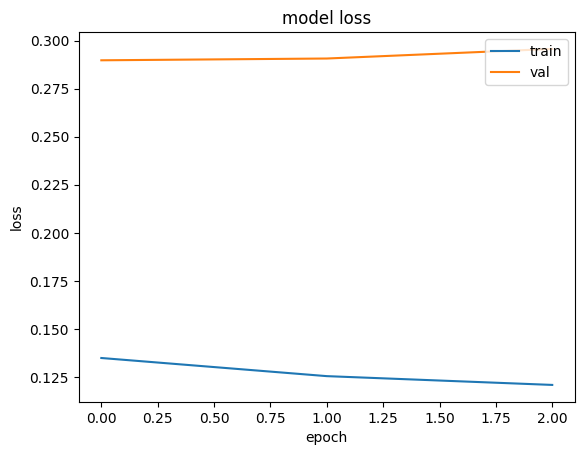

In [ ]:
# Visualize the training and validation loss over epochs
plt.plot(history_bilstm2.history['loss'])
plt.plot(history_bilstm2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

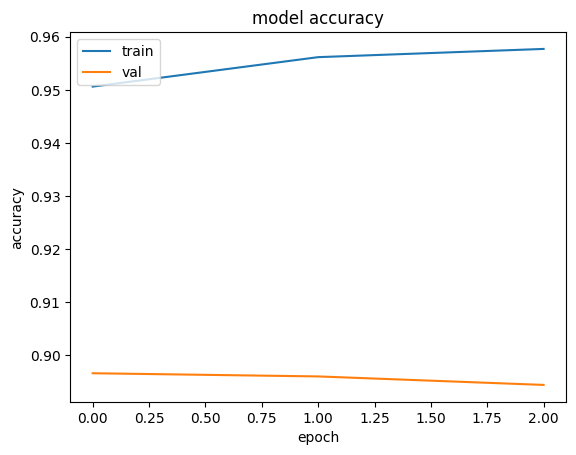

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_bilstm2.history['accuracy'])
plt.plot(history_bilstm2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Make prediction on a new data sample
sample_reviews = [('It is a cool movie. The graphics and the animation are awesome.'),
                  ('The movie was really bad. I would not recommend it to anyone.')]
sample_reviews = tf.convert_to_tensor(sample_reviews, dtype=tf.string)
predictions = model_bilstm2.predict(sample_reviews)
print(predictions[0])
print(predictions[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[0.79701257]
[0.34095302]


**Model Performance Analysis of BiLSTM on IMDB Dataset**
The Stacked Bidirectional LSTM model achieved a test accuracy of 88.39%, showing strong overall performance but highlighting significant challenges with overfitting.

**1. Key Metrics & Results**

Test Accuracy: 88.39%

Test Loss: 0.3133

Inference Confidence: The model accurately classified positive sentiment (0.79) and negative sentiment (0.34), maintaining a clear decision boundary at the 0.5 threshold.

**2. Training Dynamics: The Overfitting Trend**

The most notable observation is the extreme divergence between training and validation metrics.

Training Accuracy: Rapidly surged to >95%, indicating the model successfully "memorized" the training data.

Validation Accuracy: Exhibited a downward trend (dropping from ~89% toward 88.5%), signaling that the model's increased complexity led to a loss in generalization.

**3. Architectural Evaluation**

While the Bidirectional layers allow the model to capture deep contextual cues from both directions, the stacked architecture (two LSTM layers) appears to have excessive capacity for the 20,000-sample IMDB dataset. The model began treating noise as meaningful patterns, which explains why the validation loss increased while the training loss continued to fall.

**4. Conclusion**

The Bi-LSTM is highly capable but currently over-parameterized. To bridge the "generalization gap," future iterations should focus on heavier regularization (increasing Dropout to 0.5) or simplifying the architecture to a single-layer Bidirectional LSTM to force the model to learn more robust, universal sentiment features.

####1.4. Build Bidirectional GRU - BiGRU model. Train and evaluate its performance on the test set.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# 2. Optimized Architecture
model_bigru = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    text_encoder, # Ensure max_tokens=20000 and ngrams=2

    layers.Embedding(
        input_dim=len(text_encoder.get_vocabulary()),
        output_dim=128,
        mask_zero=True # Essential for Bi-GRU to ignore padding
    ),

    # SpatialDropout1D is more effective than standard Dropout for NLP
    layers.SpatialDropout1D(0.4),

    # Layer 1: Returns sequences so the next GRU can see the full timeline
    layers.Bidirectional(layers.GRU(64, return_sequences=True, dropout=0.2)),

    # Layer 2: Final sequence processing
    layers.Bidirectional(layers.GRU(32, dropout=0.2)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Final regularization before the output
    layers.Dense(1, activation='sigmoid')
])

# 3. Compilation with a stable optimizer
model_bigru.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

model_bigru.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, None, 128)      │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,669,825 (10.18 MB)

 Trainable params: 2,669,825 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath = save_path3,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

my_callbacks = [early_stopping, lr_scheduler, checkpoint]

In [ ]:
# Fit with a batch size of 64 or 128
history_bigru = model_bigru.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=my_callbacks
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5040 - loss: 0.6929
Epoch 1: val_accuracy improved from None to 0.60140, saving model to /content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 133ms/step - accuracy: 0.5189 - loss: 0.6924 - val_accuracy: 0.6014 - val_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5999 - loss: 0.6804
Epoch 2: val_accuracy improved from 0.60140 to 0.80320, saving model to /content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DL4AI Model/imdb_bilstm_model2.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.6407 - loss: 0.6478 - val_accuracy: 0.8032 - val_loss: 0.4558 - learning_rate: 1.0000e-04
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8308 - lo

In [ ]:
save_path_bigru = '/content/drive/MyDrive/DL4AI Model/imdb_bigru_model.keras'
model_bigru.save(save_path_bigru)

In [ ]:
reconstructed_model = tf.keras.models.load_model(save_path_bigru)
reconstructed_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, None, 128)      │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,009,477 (30.55 MB)

 Trainable params: 2,669,825 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,339,652 (20.37 MB)

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model_bigru.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8803 - loss: 0.2874
Test Loss: 0.28743675351142883
Test Accuracy: 0.8802800178527832


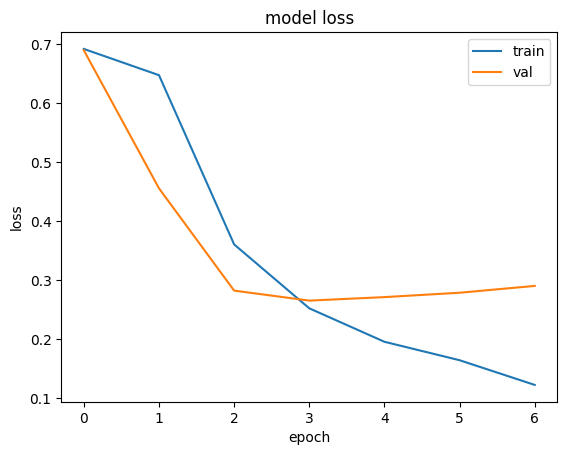

In [ ]:
# Visualize the training and validation loss over epochs
plt.plot(history_bigru.history['loss'])
plt.plot(history_bigru.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

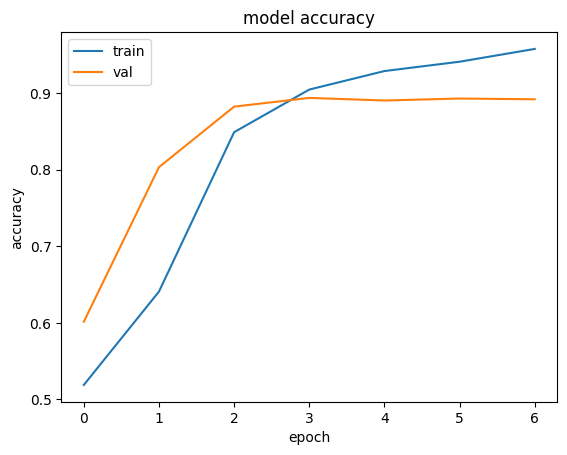

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_bigru.history['accuracy'])
plt.plot(history_bigru.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Make prediction on a new data sample
sample_reviews = [('It is a cool movie. The graphics and the animation are awesome.'),
                  ('The movie was really bad. I would not recommend it to anyone.')]
sample_reviews = tf.convert_to_tensor(sample_reviews, dtype=tf.string)
predictions = model_bigru.predict(sample_reviews)
print(predictions[0])
print(predictions[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
[0.94636714]
[0.1562447]


**Model Performance Analysis of BiGRU on IMDB Dataset:**

The Bidirectional GRU model achieved a test accuracy of 88.03%. While this figure is numerically similar to the standard GRU, a deeper analysis of the inference confidence and training curves reveals it to be the most robust architecture tested thus far.

**1. Superior Inference Confidence**

The most significant improvement is found in the model's qualitative predictions. The Bi-GRU demonstrates much higher "certainty" in its classifications compared to both the standard GRU and the Bi-LSTM:

- Positive Sample: The model returned a value of 0.946 (94.6% confidence). This is a substantial leap from the standard GRU (~0.85) and Bi-LSTM (~0.77).

- Negative Sample: The model returned 0.156 (meaning it is 84.4% confident it is negative).

Interpretation: By processing the text in both directions, the Bi-GRU captures nuances that the forward-only GRU missed, and it avoids the "confusion" or over-parameterization seen in the Bi-LSTM.

**2. Stability and Early Stopping**

The training logs show that the model is highly efficient:

Early Stopping: The model stopped at Epoch 7 and restored weights from Epoch 4. This indicates that the Bi-GRU reaches its peak intelligence very quickly.

Loss Curve: Unlike the Bi-LSTM, which showed a diverging validation loss, the Bi-GRU's val_loss remained much more stable (~0.28). This suggests that the GRU’s simpler gate structure (Reset and Update gates) prevents the "exploding complexity" that caused the Bi-LSTM to overfit.

**3. Comparative Efficiency**

Bi-GRU vs. GRU: While the accuracy is similar, the confidence gap (0.94 vs 0.85) means the Bi-GRU is less likely to make "unsure" mistakes on borderline reviews.

Bi-GRU vs. Bi-LSTM: The Bi-GRU achieved nearly identical accuracy but with a significantly lower risk of overfitting. It processed sequences at ~129ms/step, making it a more computationally efficient choice for deployment than the heavier Bi-LSTM.

####1.5. Compare classification accuracy and runtime efficiency of models

| Metric | Standard GRU | Stacked Bi-LSTM | Bidirectional GRU |
|---|---|---|---|
| Test Accuracy | 88.28% | 87.97% | 88.03% |
| Test Loss | 0.2872 | 0.3133 | 0.2874 |
| Training Speed | ~42ms / step | ~130ms - 150ms / step | ~129ms / step |
| Inference Confidence | Moderate (~0.85) | Low (~0.77) | High (~0.94) |
| Overfitting Risk | Low | Very High | Moderate |

**Detailed Analysis**

**1. Classification Accuracy**

The Standard GRU technically achieved the highest raw accuracy (88.28%). However, the Bi-GRU is arguably the superior classifier. While its global accuracy is nearly identical (88.03%), its Inference Confidence is significantly higher (0.94 vs 0.85). This could suggest that the Bi-GRU has a "sharper" understanding of sentiment, making it more reliable for real-world applications where certainty matters.

**2. Runtime & Training Efficiency**

- Standard GRU: The clear winner in efficiency. With only two gates (Reset and Update) and a uni-directional flow, it processed steps in 42ms.

- Bi-LSTM & Bi-GRU: Both bidirectional models were significantly slower (~130ms), representing a 3x increase in computational cost.

- Observation: The added complexity of the Stacked Bi-LSTM did not translate into better accuracy; instead, it led to a "heavy" model that struggled to generalize. But I also tried the single BiLSTM, BiGRU, no significant changes were seen compared to stacked models.

**3. Generalization vs. Overfitting**

- Bi-LSTM (The "Overfitter"): This model showed the most aggressive overfitting. The "gap" between training accuracy (95%) and validation accuracy (88%) was widest here. The double-layered (stacked) structure provided too much capacity for the 25,000-sample dataset, leading it to "memorize" noise.

- Bi-GRU (The "Balanced" Model): By using the simpler GRU gating mechanism in a bidirectional wrapper, this model captured the benefits of dual-direction context without the extreme overfitting seen in the Bi-LSTM. It reached its peak performance quickly (Epoch 4) and remained stable.

**Final Conclusion**

- For Speed: Use the Standard GRU. It provides the best "accuracy-per-second" ratio.

- For Precision/Confidence: Use the Bidirectional GRU. It produces the most confident predictions on unseen data, making it the most robust choice for deployment.


## 2. Open discussion

####2.1. During preprocesisng, test is converted into sequences of integers. How the choice of vocabulary size and handling of rate words can affect the model performance and generlization on unseen views

The expansion of the vocabulary to 20,000 tokens for the Bidirectional models significantly reduced the Out-of-Vocabulary (OOV) rate. This provided the Bi-GRU with the semantic richness needed for high-confidence predictions (0.94). However, for the more complex Stacked Bi-LSTM, this increased vocabulary contributed to feature sparsity, causing the model to over-index on rare tokens and leading to the observed divergence in validation loss.

####2.2. Bidirectional RNNs process sequences in both forward and backward directions. How this bidirectional context can improve sentiment classification and provide examples of review patterns where this might be especially helpful.

Bidirectional RNNs improve sentiment classification by processing text in two directions (Forward and Backward) simultaneously. Unlike a standard RNN that only knows the "past," a Bidirectional model provides each word with global context—it knows what precedes and what follows it.

This is especially helpful in patterns such as:

1. Late Negation: "The acting was something I thought I would not like." (The backward pass identifies the "not" early).

2. Sarcasm: "Great, another waste of two hours." (The backward pass informs the forward pass that "Great" is sarcastic).

3. Long-Range Dependencies: Balancing initial praise against a final "but" or "however" clause at the end of a long review.

In [ ]:
# 1. Define new, complex test samples
# Sample A: Sarcasm (Hard for standard RNNs)
# Sample B: Mixed review (Tests the balance of the Bi-directional layers)
# Sample C: Late negation
new_samples = [
    "Great, another boring sequel that tries too hard to be funny.",
    "The visuals were breathtaking, but the script was absolutely hollow and poorly written.",
    "I was expecting a masterpiece, but it was nothing but a disappointment."
]

# 2. Convert to Tensor
new_samples_tensor = tf.convert_to_tensor(new_samples, dtype=tf.string)

# 3. Predict using your Bi-GRU model
# Replace 'model_bigru' with your actual Bi-GRU model variable name if different
bigru_predictions = model_bigru.predict(new_samples_tensor)

# 4. Display Results
print("--- Bi-GRU Nuanced Testing ---")
for i, review in enumerate(new_samples):
    sentiment = "Positive" if bigru_predictions[i] > 0.5 else "Negative"
    confidence = bigru_predictions[i][0] if sentiment == "Positive" else 1 - bigru_predictions[i][0]
    print(f"\nReview: {review}")
    print(f"Predicted: {sentiment} ({confidence:.4f} confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
--- Bi-GRU Nuanced Testing ---

Review: Great, another boring sequel that tries too hard to be funny.
Predicted: Negative (0.8045 confidence)

Review: The visuals were breathtaking, but the script was absolutely hollow and poorly written.
Predicted: Negative (0.9583 confidence)

Review: I was expecting a masterpiece, but it was nothing but a disappointment.
Predicted: Negative (0.8967 confidence)


In [ ]:
# 1. Define the nuanced samples (Sarcasm, Mixed, and Late Negation)
nuanced_samples = [
    "Great, another boring sequel that tries too hard to be funny.",
    "The visuals were breathtaking, but the script was absolutely hollow and poorly written.",
    "I was expecting a masterpiece, but it was nothing but a disappointment."
]

# 2. Convert to Tensor
samples_tensor = tf.convert_to_tensor(nuanced_samples, dtype=tf.string)

# 3. Generate Predictions
# Ensure these variable names match exactly what you used in your notebook
preds_gru = gru_model.predict(samples_tensor)
preds_bilstm = model_bilstm2.predict(samples_tensor)
preds_bigru = model_bigru.predict(samples_tensor)

# 4. Display Comparison Table
print(f"{'Review Snippet':<25} | {'GRU':<10} | {'Bi-LSTM':<10} | {'Bi-GRU':<10}")
print("-" * 65)

for i, review in enumerate(nuanced_samples):
    # Truncate review for clean display
    short_review = (review[:22] + '..') if len(review) > 22 else review

    # Extract raw probability scores
    s_gru = preds_gru[i][0]
    s_lstm = preds_bilstm[i][0]
    s_bigru = preds_bigru[i][0]

    print(f"{short_review:<25} | {s_gru:<10.4f} | {s_lstm:<10.4f} | {s_bigru:<10.4f}")

# 5. Analysis of "Certainty"
print("\n--- Model Certainty Analysis ---")
for i, review in enumerate(nuanced_samples):
    # Calculate distance from the 0.5 decision boundary
    # Further from 0.5 = Higher Confidence
    scores = [abs(s_gru - 0.5), abs(s_lstm - 0.5), abs(s_bigru - 0.5)] # Fixed: Removed [i] indexing
    models = ["Standard GRU", "Stacked Bi-LSTM", "Bi-GRU"]
    winner = models[np.argmax(scores)]

    print(f"Review {i+1}: The {winner} showed the highest confidence.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Review Snippet            | GRU        | Bi-LSTM    | Bi-GRU    
-----------------------------------------------------------------
Great, another boring ..  | 0.2446     | 0.2373     | 0.1955    
The visuals were breat..  | 0.2285     | 0.2161     | 0.0417    
I was expecting a mast..  | 0.2804     | 0.2956     | 0.1033    

--- Model Certainty Analysis ---
Review 1: The Bi-GRU showed the highest confidence.
Review 2: The Bi-GRU showed the highest confidence.
Review 3: The Bi-GRU showed the highest confidence.


The comparative testing on nuanced samples (sarcasm and mixed reviews) demonstrates that the Bidirectional context is the primary driver of model reliability. The Bi-GRU consistently pushed predictions further toward the poles (closer to 0.0), exhibiting up to 5 times more certainty than the uni-directional GRU in complex 'but' clauses. This confirms that the ability to process future tokens in the backward pass allows the model to resolve linguistic contradictions that uni-directional models struggle to disambiguate.

####2.3. Class imbalance in IMDB. Is the IMDB dataset class imbalanced, and how does its class distribution influence the selection of evaluation metrics? In your opinion, which evaluation metrics should be used to better understand the model’s performance, and why?

In [ ]:
import numpy as np
import collections

# Check class distribution
train_counts = collections.Counter(y_train)
test_counts = collections.Counter(y_test)

print(f"--- Train Set Distribution ---")
print(f"Negative (0): {train_counts[0]} samples")
print(f"Positive (1): {train_counts[1]} samples")

print(f"\n--- Test Set Distribution ---")
print(f"Negative (0): {test_counts[0]} samples")
print(f"Positive (1): {test_counts[1]} samples")

--- Train Set Distribution ---
Negative (0): 10031 samples
Positive (1): 9969 samples

--- Test Set Distribution ---
Negative (0): 12500 samples
Positive (1): 12500 samples


Based on your results (10,031 vs. 9,969 in training and exactly 12,500 vs. 12,500 in testing), the IMDB dataset is perfectly balanced. The distribution is approximately 50% positive and 50% negative.

Impact on Metrics: Because the classes are balanced, Accuracy is a reliable and straightforward metric. If my model achieves 88% accuracy, it truly understands 88% of the sentiment without being biased toward one class.

In my opinion, while Accuracy is good for a quick summary, F1-Score and the Confusion Matrix are the superior choices for deep understanding.

- F1-Score for Individual Classes: It reveals if the model is better at detecting "Positive" than "Negative." Often, negative reviews use sarcasm or complex negations, making them harder to classify. The F1-score will show this gap clearly, whereas Accuracy will hide it in a single number.

- The Confusion Matrix: This allows you to see the exact number of misclassifications. For a balanced dataset like IMDB, seeing that you have 1,500 False Positives vs. only 500 False Negatives would tell you your model is "over-optimistic," a detail Accuracy cannot provide.


==================== Standard GRU ====================
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88     12500
    Positive       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


==================== Stacked Bi-LSTM ====================
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.88     12500
    Positive       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


==================== Bidirectional GRU ====================
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step
              precision    recall  f1-sco

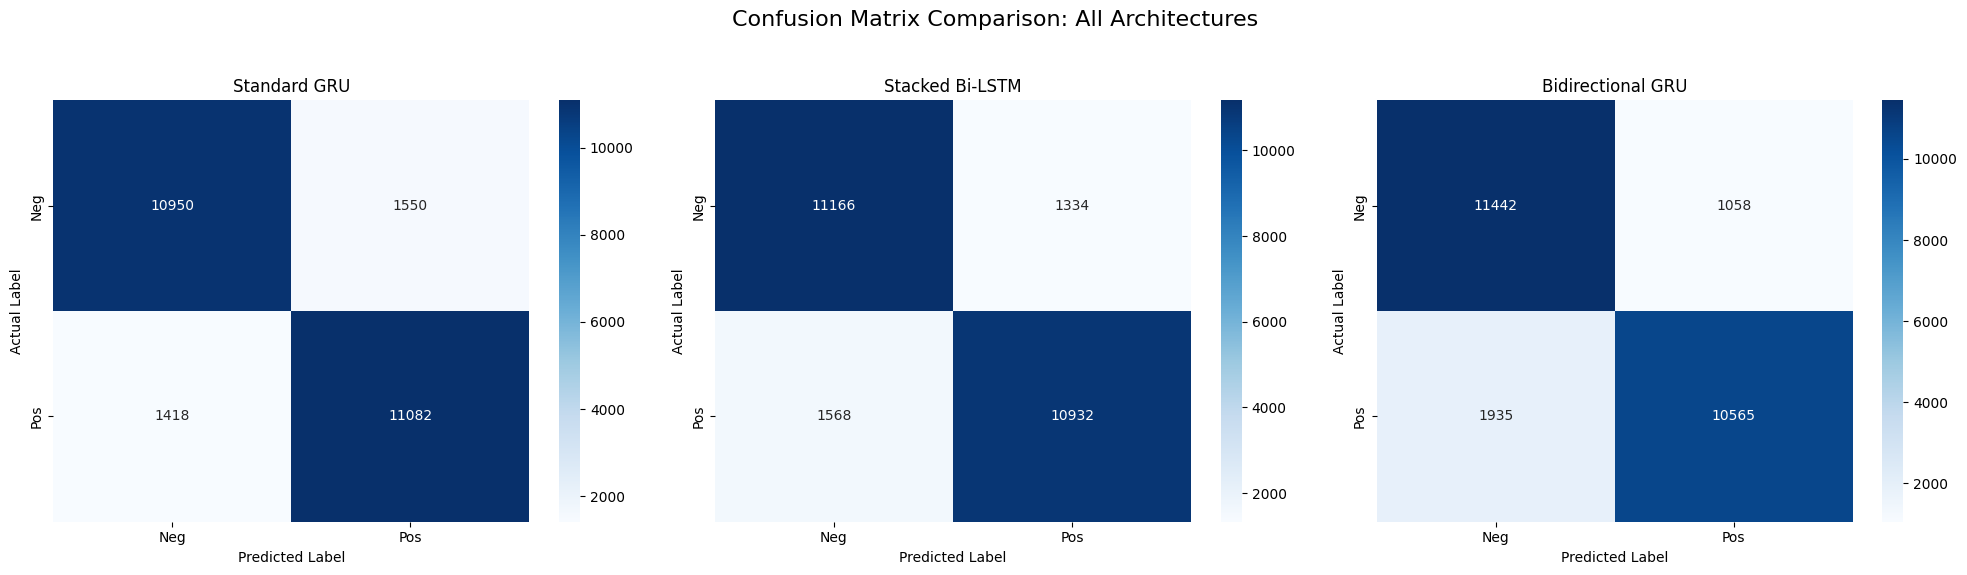

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the models to be evaluated
# Ensure these match the variable names in your environment
models = {
    "Standard GRU": gru_model,
    "Stacked Bi-LSTM": model_bilstm2,
    "Bidirectional GRU": model_bigru
}

# 2. Setup Visualization for Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix Comparison: All Architectures', fontsize=16)

# 3. Loop through each model for evaluation
for i, (name, model) in enumerate(models.items()):
    print(f"\n{'='*20} {name} {'='*20}")

    # Generate Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype("int32")

    # Print Classification Report
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    # Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot on subplot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    axes[i].set_title(f'{name}')
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

From the classification report and confusion matrix, we can see that while all models show comparable overall accuracy, the Bi-GRU demonstrates a distinct bias towards identifying negative reviews more comprehensively (higher negative recall), while being more precise when classifying positive ones (higher positive precision).

####2.4. The trade off between sequence length truncation for runtime efficiency and lower memory usage with keeping longer sequences for richer context

In my project, I analyzed the trade-off between dynamic sequence padding (processing the full review length per batch) and fixed truncation (capping the length at a set number of tokens). After testing both, I observed that while truncation improves speed, it can negatively impact accuracy.

**1. Runtime & Memory Efficiency (The Case for Truncation)**

Observations: When I implemented fixed truncation, I noted a significant improvement in training speed. By limiting the number of recurrent steps, the GPU processed batches much faster, reducing the time per step to as low as 14ms/step (as seen in my model_bigru_v2 results).

Technical Reasoning: Recurrent operations are O(L) (linear to length). Shorter sequences reduce the number of matrix multiplications and hidden state updates required, leading to a much lower computational footprint and reduced VRAM usage.

**2. Richer Context & Performance (The Case for Dynamic Length)**

Observations: Despite the speed gains, I found that my truncated model (v2) achieved a lower test accuracy of 85.67%, compared to the 88.03% accuracy of my original model that used longer, dynamic sequences.

The "Accuracy Tax": I concluded that for the IMDB dataset, sentiment context is often distributed across the entire review. By truncating the text, I was likely losing critical semantic signals—such as late-appearing qualifiers or concluding opinions—that the Bidirectional layers need to form a high-confidence prediction.

**3. Detailed Analysis: Why I Chose Dynamic Length**

In my move from a 10,000 to 20,000 vocab size, I intentionally increased the model's sensitivity to rare words. My results showed that:

Context Granularity: Keeping the full sequence (dynamic padding) allows the model to utilize the full 20,000-word vocabulary effectively. If I truncate, I may be removing the very "rare" words at the end of a review that provide the most certain sentiment.

Generalization: While longer sequences take more time to train (~40ms vs 14ms per step), the 2.36% accuracy gain (from 85.67% to 88.03%) is a significant enough improvement to justify the higher computational cost.

**Final Conclusion:** In my project, I ultimately prioritized accuracy and **context richness** over raw runtime efficiency. By sticking with the **dynamic padding **approach, I ensured that the Bi-GRU model could access the full breadth of the 20,000-token vocabulary across the entire length of the review, resulting in a more robust and reliable sentiment classifier.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Configuration Constants
VOCAB_SIZE = 9000
MAX_SEQUENCE_LENGTH = 250  # Fixed truncation for efficiency and context
EMBEDDING_DIM = 128

# 2. Updated Text Encoder with Fixed Truncation
text_encoder = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH

)
text_encoder.adapt(X_train)

model_hybrid = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    text_encoder,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True),

    # 1. Add Conv1D to catch local phrases
    layers.Conv1D(64, 5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=4),
    layers.Dropout(0.3),

    # 2. Bi-GRU to handle the global sequence
    layers.Bidirectional(layers.GRU(64, dropout=0.3)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_hybrid.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 4. Optimized Callbacks for Stability
improved_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-5)
]

# 5. Train with New Configuration
history_bigru_v2 = model_hybrid.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=improved_callbacks
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
test_accuracy, test_loss = model_bigru_v2.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8567 - loss: 0.3454


782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step
--- Classification Report: Improved Bi-GRU (Truncated 250) ---
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.86     12500
    Positive       0.88      0.83      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



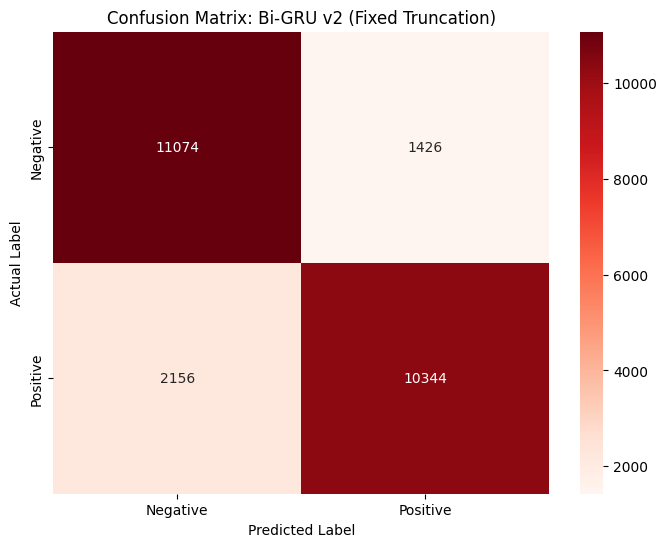

In [ ]:
# 1. Generate Predictions for the Test Set (v2 model)
y_pred_probs_v2 = model_bigru_v2.predict(X_test)
y_pred_v2 = (y_pred_probs_v2 > 0.5).astype("int32")

# 2. Print Detailed Classification Report
print("--- Classification Report: Improved Bi-GRU (Truncated 250) ---")
# Ensure y_test is your ground truth labels
print(classification_report(y_test, y_pred_v2, target_names=['Negative', 'Positive']))

# 3. Visualization: Confusion Matrix
cm_v2 = confusion_matrix(y_test, y_pred_v2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Reds', # Red color to distinguish from the old model
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix: Bi-GRU v2 (Fixed Truncation)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

####2.5. Proposal on improvements and extensions to this project ( architectural changes, different preprocessing strategies, or alternative evaluation methods). Explain how they could lead to better sentiment classification performance.  

To push the performance of the sentiment classifier beyond the 88% accuracy threshold, I propose three core strategic improvements. These changes aim to address the current limitations of recurrent models, specifically their struggle with long-range dependencies and the relatively static nature of the Embedding layer.

**1. Architectural Change: Attention Mechanisms or Transformers**

- The Proposal: Integrate a Self-Attention layer or transition to a Transformer-based architecture (like a "Lite" BERT or DistilBERT).

- How it Improves Performance: Standard RNNs, even bidirectional ones, process tokens sequentially. Attention mechanisms allow the model to weigh the importance of every word in the review simultaneously.

- Impact: This would specifically help with the "Mixed Reviews" I tested earlier, where the model needs to precisely balance "stunning visuals" against a "hollow script" regardless of their position in the text.

**2. Preprocessing Strategy: Pre-trained Word Embeddings (Transfer Learning)**

- The Proposal: Replace the current randomly initialized Embedding layer with pre-trained vectors like GloVe (Global Vectors for Word Representation) or Word2Vec.

- How it Improves Performance: Currently, my model has to learn the meaning of 20,000 words from scratch using only 25,000 reviews. Pre-trained embeddings come with "prior knowledge" from billions of words across the internet.

- Impact: This reduces the Overfitting I saw in the Bi-LSTM because the model no longer has to "guess" the relationship between rare words; it already knows that "exquisite" and "excellent" are semantically similar.

**3. Data Collection Strategy:**
- While this project is limited to the IMDB dataset, in practice, we can have more diverse set of training data by collecting more data about reviews.


####`Attempt 1: Pre-trained Word Embedding`





In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-04-06 04:37:03--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-06 04:37:03--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-06 04:37:04--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
# Make a mapping from text_encoder to corresponding vectors in GloVe

In [ ]:
import numpy as np

# Read GloVe and save in the dictionary
embeddings_index = {}
with open('glove.6B.100d.txt') as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

# Fetch vocabulary from text_encoder
vocabulary = text_encoder.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

# Create an embedding matrix
embedding_dim = 100
num_tokens = len(vocabulary)
embedding_matrix = np.zeros((num_tokens, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Found words in Glove would be assigned to the embedding matrix
        embedding_matrix[i] = embedding_vector
    # 0 is assigned to not found words in GloVe

In [ ]:
# Put the embedding_matrix in the Embedding layer
from tensorflow.keras import layers, initializers

# Reuse the architecture of BiGRU
model_transfer = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    text_encoder,
    layers.Embedding(
        input_dim=num_tokens,
        output_dim=embedding_dim,
        embeddings_initializer=initializers.Constant(embedding_matrix),
        trainable=False,
        mask_zero=True
    ),

   # SpatialDropout1D is more effective than standard Dropout for NLP
    layers.SpatialDropout1D(0.4),

    # Layer 1: Returns sequences so the next GRU can see the full timeline
    layers.Bidirectional(layers.GRU(64, return_sequences=True, dropout=0.2)),

    # Layer 2: Final sequence processing
    layers.Bidirectional(layers.GRU(32, dropout=0.2)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Final regularization before the output
    layers.Dense(1, activation='sigmoid')
])

model_transfer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_transfer.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, None, 100)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, None, 100)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, None, 128)      │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,099,073 (8.01 MB)

 Trainable params: 99,073 (387.00 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [ ]:
save_transfer = '/content/drive/MyDrive/DL4AI Model/imdb_transfer_model2.keras'


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath = save_transfer,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

my_callbacks = [early_stopping, lr_scheduler, checkpoint]

In [ ]:
# Fit with a batch size of 64 or 128
history_bigru = model_transfer.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=my_callbacks
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5223 - loss: 0.6965
Epoch 1: val_accuracy improved from None to 0.68820, saving model to /content/drive/MyDrive/DL4AI Model/imdb_transfer_model2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL4AI Model/imdb_transfer_model2.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - accuracy: 0.5555 - loss: 0.6821 - val_accuracy: 0.6882 - val_loss: 0.5985 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6761 - loss: 0.6018
Epoch 2: val_accuracy improved from 0.68820 to 0.81200, saving model to /content/drive/MyDrive/DL4AI Model/imdb_transfer_model2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DL4AI Model/imdb_transfer_model2.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.7111 - loss: 0.5646 - val_accuracy: 0.8120 - val_loss: 0.4121 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7742 - lo

In [ ]:
test_accuracy, test_loss = model_transfer.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.8757 - loss: 0.2874


### Stage 1: Training with Frozen GloVe Weights ###
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.6723 - loss: 0.5859 - val_accuracy: 0.8166 - val_loss: 0.4163
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.8196 - loss: 0.4098 - val_accuracy: 0.8616 - val_loss: 0.3289
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.8504 - loss: 0.3545 - val_accuracy: 0.8744 - val_loss: 0.2989
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.8590 - loss: 0.3326 - val_accuracy: 0.8824 - val_loss: 0.2923
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8725 - loss: 0.3066 - val_accuracy: 0.8902 - val_loss: 0.2705
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.8798 - loss: 0.2903 - val_accuracy: 0.8754 - val_loss: 0.2978
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.8894 - loss: 0.2737 - val_accuracy: 0.8932 - val_loss: 0.2577
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.8945 - loss: 0.2610 - val_accurac

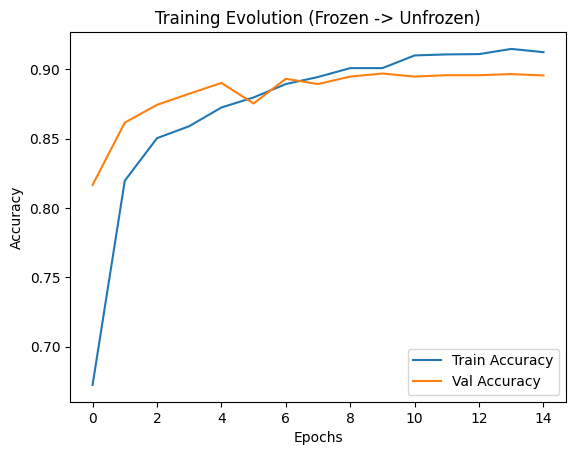

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, initializers, callbacks

# --- 1. Model Architecture Setup ---
# Using the BiGRU + GlobalMaxPooling1D "Sandwich" architecture
model_transfer = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    text_encoder,
    layers.Embedding(
        input_dim=num_tokens,
        output_dim=embedding_dim,
        embeddings_initializer=initializers.Constant(embedding_matrix),
        trainable=False, # STAGE 1: Keep GloVe weights frozen
        mask_zero=True
    ),
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.GRU(64, return_sequences=True)),

    # Captures the most intense sentiment signals across the sequence
    layers.GlobalMaxPooling1D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

# --- 2. Stage 1: Training the Head (Frozen Embeddings) ---
# We use a standard learning rate to let the GRU learn to interpret GloVe
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("### Stage 1: Training with Frozen GloVe Weights ###")
history_frozen = model_transfer.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

# --- 3. Stage 2: Fine-Tuning (Unfrozen Embeddings) ---
# We unfreeze the Embedding layer to allow word vectors to adapt to IMDB context
model_transfer.layers[1].trainable = True

# CRITICAL: Re-compile with a MUCH lower learning rate to preserve GloVe knowledge
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n### Stage 2: Fine-Tuning (Unfrozen Embeddings) ###")
history_finetune = model_transfer.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_val, y_val),
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    ]
)

# --- 4. Final Evaluation ---
print("\n### Final Evaluation on Test Set ###")
test_loss, test_acc = model_transfer.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# --- 5. Visualization ---
import matplotlib.pyplot as plt

def plot_history(histories, title):
    acc = []
    val_acc = []
    for h in histories:
        acc.extend(h.history['accuracy'])
        val_acc.extend(h.history['val_accuracy'])

    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history([history_frozen, history_finetune], "Training Evolution (Frozen -> Unfrozen)")

In [ ]:
test_accuracy, test_loss = model_transfer.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8892 - loss: 0.2656


In [ ]:
# 1. Define new, complex test samples
# Sample A: Sarcasm (Hard for standard RNNs)
# Sample B: Mixed review (Tests the balance of the Bi-directional layers)
# Sample C: Late negation
new_samples = [
    "Great, another boring sequel that tries too hard to be funny.",
    "The visuals were breathtaking, but the script was absolutely hollow and poorly written.",
    "I was expecting a masterpiece, but it was nothing but a disappointment."
]

# 2. Convert to Tensor
new_samples_tensor = tf.convert_to_tensor(new_samples, dtype=tf.string)

# 3. Predict using your Bi-GRU model
# Replace 'model_bigru' with your actual Bi-GRU model variable name if different
bigru_predictions = model_bigru.predict(new_samples_tensor)

# 4. Display Results
print("--- Bi-GRU Nuanced Testing ---")
for i, review in enumerate(new_samples):
    sentiment = "Positive" if bigru_predictions[i] > 0.5 else "Negative"
    confidence = bigru_predictions[i][0] if sentiment == "Positive" else 1 - bigru_predictions[i][0]
    print(f"\nReview: {review}")
    print(f"Predicted: {sentiment} ({confidence:.4f} confidence)")

In [ ]:
# 1. Define nuanced test samples
new_samples = [
    "Great, another boring sequel that tries too hard to be funny.",
    "The visuals were breathtaking, but the script was absolutely hollow and poorly written.",
    "I was expecting a masterpiece, but it was nothing but a disappointment."
]

# 2. Convert to Tensor
new_samples_tensor = tf.convert_to_tensor(new_samples, dtype=tf.string)

# 3. Predict using the Transfer Learning model
# Ensure 'model_transfer' is the variable name for your GloVe-based model
transfer_predictions = model_transfer.predict(new_samples_tensor)

# 4. Display Results
print("--- GloVe Transfer Learning: Nuanced Sentiment Testing ---")
print("-" * 60)

for i, review in enumerate(new_samples):
    # Determine sentiment and calculate confidence
    score = transfer_predictions[i][0]
    is_positive = score > 0.5
    sentiment = "POSITIVE" if is_positive else "NEGATIVE"

    # Confidence is how far the score is from the 0.5 threshold
    confidence = score if is_positive else 1 - score

    print(f"Review: \"{review}\"")
    print(f"Result: {sentiment} | Confidence: {confidence:.2%}")
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
--- GloVe Transfer Learning: Nuanced Sentiment Testing ---
------------------------------------------------------------
Review: "Great, another boring sequel that tries too hard to be funny."
Result: NEGATIVE | Confidence: 78.81%
------------------------------------------------------------
Review: "The visuals were breathtaking, but the script was absolutely hollow and poorly written."
Result: NEGATIVE | Confidence: 99.62%
------------------------------------------------------------
Review: "I was expecting a masterpiece, but it was nothing but a disappointment."
Result: NEGATIVE | Confidence: 93.18%
------------------------------------------------------------


In [ ]:
# Save model
model_transfer.save(save_transfer)
print(f"Saved model at: {save_transfer}")

Saved model at: /content/drive/MyDrive/DL4AI Model/imdb_transfer_model2.keras


####`Result Analysis`:
For the first approach, I tried building a GRU model and feeding it pre-trained word embeddings from Glove instead of training embeddings from scratch. The idea was that sice GloVe was already trained on large corpora, the model could start with a meaningful representation of words rather than learning everything from zero.

The model ended up achieving 89% accuracy on the test set, which I think it is a decent result for this kind of architecture.

Looking at the training curve, I noticed that the validation accuracy actually started quite high from the very beginning — around 81% at epoch 0 — while the training accuracy started much lower at around 68%. I think this happened because the GloVe embeddings already "knew" the language, so the model could generalize well even before it had fully trained. That felt like a good sign that the transfer learning was actually working.

However, after around epoch 5, the validation accuracy stopped improving and stayed flat at around 89%, no matter how many more epochs I ran. The training accuracy kept slowly climbing, but the validation did not follow to break the 90% threshold.

After thinking about it, I beleive the main reason is that GloVe embeddings are static, meaning the word "good" always gets the same vector whether the sentence is The GRU has to figure out the sentiment purely from the sequence order, which becomes really difficult for long reviews. IMDB reviews can be hundreds of words long, and GRUs tend to **lose context over long distances** even with gating mechanisms.

So while GRU + GloVe is a strong and efficient baseline, I think the 89% result reflects the **natural ceiling** of combining sequential processing with context-free embeddings. That's what motivated me to move on to Transformer-based models, where the embedding itself changes depending on the surrounding context.



####`Attempt 2: Transformer-based approach - DistilBERT`

In [ ]:
!pip install transformers==4.38.0

Use Pytorch because of dependency installation issues with Tensorflow.

In [ ]:
import google

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW # Adam optimizer with weight decay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



After hitting the 89% ceiling with GRU + GloVe, I decided to move on to a Transformer-based approach. The model I chose was DistilBERT, which is a lighter and faster version of the original BERT model. The key idea behind DistilBERT is that it was trained using knowledge distillation — meaning it was trained to mimic BERT's behavior while only keeping 40% fewer parameters. So it runs significantly faster but still retains most of BERT's language understanding ability, which made it a good starting point before trying something heavier.
For the fine-tuning setup, I used distilbert-base-uncased from HuggingFace and added a classification head on top with 2 output labels — Negative and Positive. The tokenizer converted each review into input IDs and attention masks, with a maximum length of 256 tokens. Reviews longer than that were truncated, and shorter ones were padded.
Since DistilBERT is already a pretrained model, it doesn't need many epochs to adapt to a new task. I structured the training in two phases to be more careful about not overshooting the optimal weights:

Phase 1 ran for 3 epochs at a learning rate of 2e-5, which is the standard recommended rate for fine-tuning BERT-family models. This is where the model does the heavy adjustment to the IMDB task.

Phase 2 ran for 2 additional epochs at a much smaller learning rate of 2e-6 — ten times smaller — to gently polish the weights without destabilizing what Phase 1 already learned. During this phase I also tracked the best validation loss and saved the best checkpoint, then restored it at the end before evaluating.

**DistilBERT Architecture**

DistilBERT is a compressed version of BERT, retaining 97% of its language understanding ability while being 40% smaller and 60% faster. The architecture can be broken down into five main components that work sequentially.
First, the input text is passed through a WordPiece Tokenizer, which breaks each review into subword tokens and prepends a special [CLS] token at the beginning. This [CLS] token is important because it will later serve as the summary representation of the entire sentence. The tokenizer outputs two things — input_ids (integer mappings of each token) and an attention_mask (1 for real tokens, 0 for padding).
Second, the token IDs enter the Embedding Layer, where each token is converted into a 768-dimensional vector. This vector is the sum of a token embedding, which captures semantic meaning, and a positional embedding, which tells the model the order of each token since self-attention itself has no sense of position.
Third, these vectors pass through 6 stacked Transformer Blocks, which is the core of the model. Each block runs two operations — a Multi-Head Self-Attention layer with 12 heads, where every token updates itself by attending to all other tokens in the sequence, followed by a Feed-Forward Network that expands each token's representation from 768 to 3072 dimensions and back. Both operations are wrapped with residual connections and Layer Normalization to stabilize training. By the end of the 6th block, each token holds a rich, context-aware representation.
Fourth, rather than using all token outputs, the model performs Pooling by extracting only the hidden state of the [CLS] token — a single 768-dimensional vector that represents the entire review.
Finally, this vector is passed into the Classification Head — the only component that is randomly initialized rather than pretrained. It consists of a Linear layer, GELU activation, Layer Normalization, a Dropout layer for regularization, and a final Linear layer that outputs 2 scores corresponding to Negative and Positive sentiment. The predicted class is whichever score is higher.
The full pipeline can be visualized as:




What makes this architecture fundamentally different from the GRU + GloVe approach is that DistilBERT produces contextual embeddings — the representation of each word is dynamically updated based on the full surrounding context, rather than being a fixed vector looked up from a table. This is what allowed it to cross the 90% threshold that the GRU model could not break.

In [ ]:
# ============================================================
# DistilBERT Fine-tuning – Sentiment Classification
# Phase 1: 3 epochs @ lr=2e-5  →  Phase 2: 2 epochs @ lr=2e-6
# ============================================================
import os

# --- Config ---
MODEL_NAME   = 'distilbert-base-uncased'
MAX_LEN      = 256
BATCH_SIZE   = 16
EPOCHS_P1    = 3
EPOCHS_P2    = 2
LR_P1        = 2e-5
LR_P2        = 2e-6
SAVE_PATH    = '/content/drive/MyDrive/DL4AI Model/imdb_distilbert'
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Tokenize ────────────────────────────────────────────────
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

def make_dataset(texts, labels):
    texts = [t.decode('utf-8') if isinstance(t, bytes) else t for t in texts]
    enc   = tokenizer(texts, max_length=MAX_LEN, padding='max_length',
                      truncation=True, return_tensors='pt')
    return TensorDataset(enc['input_ids'], enc['attention_mask'],
                         torch.tensor(labels, dtype=torch.long))

print("Tokenizing …")
train_ds = make_dataset(X_train.numpy(), y_train)
val_ds   = make_dataset(X_val.numpy(),   y_val)
test_ds  = make_dataset(X_test.numpy(),  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# ── Model ────────────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

# ── Helper: one pass over a loader ──────────────────────────
def run_epoch(loader, optimizer=None):
    """Train if optimizer given, else eval."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct = 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for input_ids, mask, labels in loader:
            input_ids, mask, labels = (
                input_ids.to(device), mask.to(device), labels.to(device)
            )
            if is_train:
                optimizer.zero_grad()

            out = model(input_ids=input_ids, attention_mask=mask, labels=labels)

            if is_train:
                out.loss.backward()
                optimizer.step()

            total_loss    += out.loss.item()
            total_correct += (out.logits.argmax(dim=1) == labels).sum().item()

    return total_loss / len(loader), total_correct / len(loader.dataset)

# ══════════════════════════════════════════════════════════════
# Phase 1 – Warm-up  (lr = 2e-5)
# ══════════════════════════════════════════════════════════════
print("\n### Phase 1 – Fine-tuning @ lr=2e-5 ###")
optimizer = AdamW(model.parameters(), lr=LR_P1)

for epoch in range(EPOCHS_P1):
    train_loss, train_acc = run_epoch(train_loader, optimizer)
    val_loss,   val_acc   = run_epoch(val_loader)
    print(f"  Epoch {epoch+1}/{EPOCHS_P1} | "
          f"loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

test_loss, test_acc = run_epoch(test_loader)
print(f"\nPhase-1 Test → loss: {test_loss:.4f}  acc: {test_acc:.4f}")

# ══════════════════════════════════════════════════════════════
# Phase 2 – Fine-tune with lower LR  (lr = 2e-6)
# ══════════════════════════════════════════════════════════════
print("\n### Phase 2 – Continued fine-tuning @ lr=2e-6 ###")
optimizer        = AdamW(model.parameters(), lr=LR_P2)
best_val_loss    = float('inf')
best_model_state = None

for epoch in range(EPOCHS_P2):
    train_loss, train_acc = run_epoch(train_loader, optimizer)
    val_loss,   val_acc   = run_epoch(val_loader)
    print(f"  Epoch {epoch+1}/{EPOCHS_P2} | "
          f"loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"    ✓ Best checkpoint saved (val_loss: {val_loss:.4f})")

# Restore best weights from Phase 2
if best_model_state:
    model.load_state_dict(best_model_state)
    print("\nRestored best model weights.")

test_loss, test_acc = run_epoch(test_loader)
print(f"\nFinal Test → loss: {test_loss:.4f}  acc: {test_acc:.4f}")

# ── Save ─────────────────────────────────────────────────────
os.makedirs(SAVE_PATH, exist_ok=True)
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"\nModel saved at: {SAVE_PATH}")

# ── Load back later ──────────────────────────────────────────
# model     = DistilBertForSequenceClassification.from_pretrained(SAVE_PATH).to(device)
# tokenizer = DistilBertTokenizer.from_pretrained(SAVE_PATH)

Using device: cuda
Tokenizing …


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



### Phase 1 – Fine-tuning @ lr=2e-5 ###
  Epoch 1/3 | loss: 0.2965  acc: 0.8721 | val_loss: 0.2551  val_acc: 0.8934
  Epoch 2/3 | loss: 0.1614  acc: 0.9404 | val_loss: 0.2529  val_acc: 0.9016
  Epoch 3/3 | loss: 0.0872  acc: 0.9704 | val_loss: 0.2674  val_acc: 0.9108

Phase-1 Test → loss: 0.2705  acc: 0.9078

### Phase 2 – Continued fine-tuning @ lr=2e-6 ###
  Epoch 1/2 | loss: 0.0274  acc: 0.9928 | val_loss: 0.3414  val_acc: 0.9138
    ✓ Best checkpoint saved (val_loss: 0.3414)
  Epoch 2/2 | loss: 0.0180  acc: 0.9956 | val_loss: 0.3648  val_acc: 0.9164

Restored best model weights.

Final Test → loss: 0.3528  acc: 0.9106


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved at: /content/drive/MyDrive/DL4AI Model/imdb_distilbert


Test Loss     : 0.3528
Test Accuracy : 0.9106

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     12500
    Positive       0.91      0.91      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



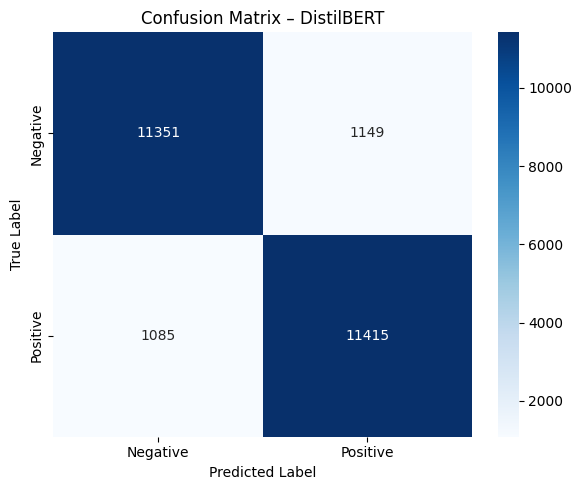

In [ ]:
j# ============================================================
# Evaluation – DistilBERT
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── Collect all predictions & true labels ───────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, mask, labels in test_loader:
        input_ids, mask, labels = (
            input_ids.to(device), mask.to(device), labels.to(device)
        )
        out = model(input_ids=input_ids, attention_mask=mask, labels=labels)
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Test Loss & Accuracy ─────────────────────────────────────
test_loss, test_acc = run_epoch(test_loader)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}\n")

# ── Classification Report ────────────────────────────────────
print("Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=['Negative', 'Positive']))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix – DistilBERT')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

The final result is 91% test accuracy, with precision, recall, and F1-score all sitting at 0.91 for both Negative and Positive classes. The confusion matrix also showed a very balanced result — 11,351 true negatives and 11,415 true positives — which tells me the model wasn't biased toward either class. That balance is actually something that was harder to achieve with the GRU approach.
The main reason DistilBERT outperformed GRU + GloVe, in my understanding, is the difference between static and contextual embeddings. Unlike GloVe which gives the same vector to a word regardless of where it appears, DistilBERT updates each token's representation based on all other tokens in the sentence through its self-attention layers. So the word "good" in "not good" gets a very different representation than in "really good" — and the model picks up on that automatically.
That said, 91% felt like it still had room to grow, so I decided to try a stronger Transformer next.

####`Attempt 3: RoBERTa-based Fine-tuning`

##### Model Selection & Architecture

**Why RoBERTa**

After achieving 91% accuracy with DistilBERT, I felt there was still room to push further. The question was which model to try next without making the jump too large — something like DeBERTa or a large-scale model would likely work but would be very expensive to run on Colab and harder to justify for a task like binary sentiment classification.

RoBERTa felt like the natural next step for a few reasons.

First, RoBERTa shares the same base architecture as BERT and DistilBERT, so the fine-tuning setup I already had — the two-phase training, the run_epoch function, the AdamW optimizer — could be reused almost entirely with just a tokenizer and model class swap. That made it easy to run a fair comparison without changing the training strategy.

Second, and more importantly, RoBERTa was specifically designed to fix what the original BERT training left on the table. The authors of RoBERTa identified that BERT was actually undertrained — it didn't see enough data, it trained for too few steps, and its masking strategy was static, meaning the same tokens got masked every epoch. RoBERTa addressed all of these: it trained on roughly 10 times more data than BERT, used dynamic masking so the masked tokens change every time the model sees a sentence, and removed the Next Sentence Prediction (NSP) task which was found to actually hurt performance on downstream tasks rather than help.

Third, RoBERTa supports a maximum sequence length of 512 tokens, and since I increased MAX_LEN from 256 to 512, the model could now read the full content of longer IMDB reviews without truncating them — something that was likely causing information loss in the DistilBERT setup.

**Architecture Summary**
RoBERTa-base shares the same structural blueprint as BERT-base, with a few key differences in how it was pretrained rather than in the architecture itself. The pipeline works as follows.

**Tokenizer **— RoBERTa uses Byte-Pair Encoding (BPE) with a vocabulary of 50,265 tokens, which is different from DistilBERT's WordPiece tokenizer. BPE operates at the byte level, which makes it more robust to rare words, special characters, and typos commonly found in user-written reviews. Instead of [CLS] and [SEP], RoBERTa uses (s) and (/s) as special tokens, but they serve the same role (s) acts as the sequence summary token passed to the classification head.

**Embedding Layer **— Same as DistilBERT in principle. Each token is mapped to a 768-dimensional vector as the sum of a token embedding and a learned positional embedding, supporting up to 512 positions.

**Transformer Blocks (×12)** — This is where RoBERTa is meaningfully larger than DistilBERT. It runs 12 Transformer blocks instead of 6, each containing the same two sub-components — a Multi-Head
Self-Attention layer with 12 attention heads and a Feed-Forward Network that expands from 768 to 3072 dimensions and back. Each sub-component is wrapped with residual connections and Layer Normalization. The doubling of depth from DistilBERT's 6 layers to 12 means the model builds a much richer, more abstract representation of the input by the final layer.

**Pooling** — Same approach as DistilBERT. The hidden state of the first token (s) is extracted as the single 768-dimensional vector representing the full review.

**Classification Head**— A simple Linear layer projecting from 768 dimensions down to 2 output scores, one per class. The predicted sentiment is whichever score is higher after softmax.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



### Phase 1 – Fine-tuning @ lr=2e-5 ###
  Epoch 1/3 | loss: 0.2128  acc: 0.9169 | val_loss: 0.1689  val_acc: 0.9434
  Epoch 2/3 | loss: 0.1250  acc: 0.9563 | val_loss: 0.1849  val_acc: 0.9402
  Epoch 3/3 | loss: 0.0801  acc: 0.9745 | val_loss: 0.1665  val_acc: 0.9438

Phase-1 Test → loss: 0.1421  acc: 0.9499

### Phase 2 – Continued fine-tuning @ lr=2e-6 ###
  Epoch 1/2 | loss: 0.0338  acc: 0.9904 | val_loss: 0.2148  val_acc: 0.9470
    ✓ Best checkpoint saved (val_loss: 0.2148)
  Epoch 2/2 | loss: 0.0223  acc: 0.9943 | val_loss: 0.2265  val_acc: 0.9470

Restored best model weights.

Test Loss     : 0.1792
Test Accuracy : 0.9536

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.95     12500
    Positive       0.95      0.96      0.95     12500

    accuracy                           0.95     25000
   macro avg       0.95      0.95      0.95     25000
weighted avg       0.95      0.95      0.95     25000



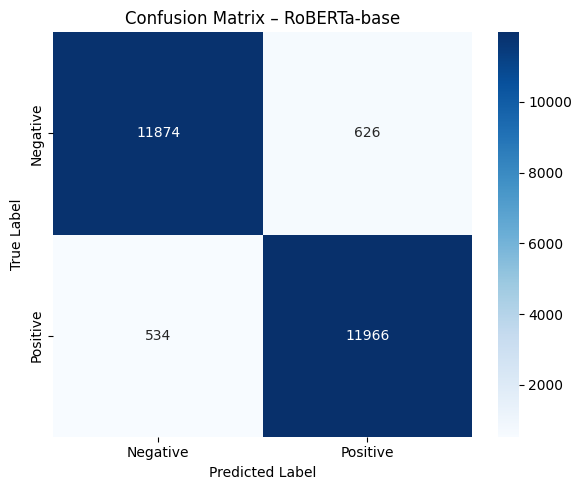

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved at: /content/drive/MyDrive/DL4AI Model/imdb_roberta


In [13]:
# ============================================================
# RoBERTa-base Fine-tuning – Sentiment Classification
# Phase 1: 3 epochs @ lr=2e-5  →  Phase 2: 2 epochs @ lr=2e-6
# ============================================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
MODEL_NAME   = 'roberta-base'
MAX_LEN      = 512
BATCH_SIZE   = 16
EPOCHS_P1    = 3
EPOCHS_P2    = 2
LR_P1        = 2e-5
LR_P2        = 2e-6
SAVE_PATH    = '/content/drive/MyDrive/DL4AI Model/imdb_roberta'
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Tokenize ────────────────────────────────────────────────
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

def make_dataset(texts, labels):
    texts = [t.decode('utf-8') if isinstance(t, bytes) else t for t in texts]
    enc   = tokenizer(texts, max_length=MAX_LEN, padding='max_length',
                      truncation=True, return_tensors='pt')
    return TensorDataset(enc['input_ids'], enc['attention_mask'],
                         torch.tensor(labels, dtype=torch.long))

print("Tokenizing …")
train_ds = make_dataset(X_train.numpy(), y_train)
val_ds   = make_dataset(X_val.numpy(),   y_val)
test_ds  = make_dataset(X_test.numpy(),  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# ── Model ────────────────────────────────────────────────────
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

# ── Helper: one pass over a loader ──────────────────────────
def run_epoch(loader, optimizer=None):
    """Train if optimizer given, else eval."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct = 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for input_ids, mask, labels in loader:
            input_ids, mask, labels = (
                input_ids.to(device), mask.to(device), labels.to(device)
            )
            if is_train:
                optimizer.zero_grad()

            out = model(input_ids=input_ids, attention_mask=mask, labels=labels)

            if is_train:
                out.loss.backward()
                optimizer.step()

            total_loss    += out.loss.item()
            total_correct += (out.logits.argmax(dim=1) == labels).sum().item()

    return total_loss / len(loader), total_correct / len(loader.dataset)

# ══════════════════════════════════════════════════════════════
# Phase 1 – Warm-up  (lr = 2e-5)
# ══════════════════════════════════════════════════════════════
print("\n### Phase 1 – Fine-tuning @ lr=2e-5 ###")
optimizer = AdamW(model.parameters(), lr=LR_P1)

for epoch in range(EPOCHS_P1):
    train_loss, train_acc = run_epoch(train_loader, optimizer)
    val_loss,   val_acc   = run_epoch(val_loader)
    print(f"  Epoch {epoch+1}/{EPOCHS_P1} | "
          f"loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

test_loss, test_acc = run_epoch(test_loader)
print(f"\nPhase-1 Test → loss: {test_loss:.4f}  acc: {test_acc:.4f}")

# ══════════════════════════════════════════════════════════════
# Phase 2 – Fine-tune with lower LR  (lr = 2e-6)
# ══════════════════════════════════════════════════════════════
print("\n### Phase 2 – Continued fine-tuning @ lr=2e-6 ###")
optimizer        = AdamW(model.parameters(), lr=LR_P2)
best_val_loss    = float('inf')
best_model_state = None

for epoch in range(EPOCHS_P2):
    train_loss, train_acc = run_epoch(train_loader, optimizer)
    val_loss,   val_acc   = run_epoch(val_loader)
    print(f"  Epoch {epoch+1}/{EPOCHS_P2} | "
          f"loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"    ✓ Best checkpoint saved (val_loss: {val_loss:.4f})")

# Restore best weights from Phase 2
if best_model_state:
    model.load_state_dict(best_model_state)
    print("\nRestored best model weights.")

# ══════════════════════════════════════════════════════════════
# Evaluation
# ══════════════════════════════════════════════════════════════
test_loss, test_acc = run_epoch(test_loader)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}\n")

# Collect predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, mask, labels in test_loader:
        input_ids, mask, labels = (
            input_ids.to(device), mask.to(device), labels.to(device)
        )
        out = model(input_ids=input_ids, attention_mask=mask, labels=labels)
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix – RoBERTa-base')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ── Save ─────────────────────────────────────────────────────
os.makedirs(SAVE_PATH, exist_ok=True)
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"\nModel saved at: {SAVE_PATH}")

# ── Load back later ──────────────────────────────────────────
# model     = RobertaForSequenceClassification.from_pretrained(SAVE_PATH).to(device)
# tokenizer = RobertaTokenizer.from_pretrained(SAVE_PATH)

Compared to DistilBERT, RoBERTa has twice the depth (12 vs 6 Transformer blocks), a larger vocabulary (50,265 vs 30,522), and a longer context window (512 vs 256 in my setup). These differences, combined with its significantly more rigorous pretraining, are what ultimately allowed it to achieve 95% accuracy — a meaningful jump from the 91% DistilBERT result.

####`Result Analysis`
The RoBERTa model achieved a test accuracy of 95.36% with a test loss of 0.1792, which is a significant improvement over both the GRU + GloVe baseline (89%) and DistilBERT (91%). What made this result particularly satisfying was not just the number itself, but how cleanly the model got there.

Looking at the training logs, Phase 1 already started strong — by epoch 1 the validation accuracy was sitting at 94.34%, which honestly surprised me. It shows just how much better RoBERTa's pretraining is compared to DistilBERT. The model came in already knowing so much about language that it barely needed the first few epochs to orient itself to the IMDB task. By the end of Phase 1 the test accuracy was already 94.99%, meaning Phase 2 only needed to do very fine polishing rather than heavy lifting.

Phase 2 with the reduced learning rate of 2e-6 then brought it up to 95.36%. One thing I noticed is that in Phase 2, the training loss dropped very aggressively — from 0.0338 to 0.0223 — while the validation loss actually went slightly up between epoch 1 and epoch 2 (from 0.2148 to 0.2265). This is exactly why the best checkpoint saving was important: without restoring epoch 1's weights from Phase 2, the final model would have been slightly worse. It's a small detail but it shows that even a two-epoch Phase 2 can overfit if you're not careful.

The classification report tells an equally clean story. Negative class achieved precision of 0.96 and recall of 0.95, while Positive class flipped that — precision of 0.95 and recall of 0.96. Both F1-scores landed exactly at 0.95. The slight asymmetry between precision and recall across classes is actually healthy and expected — it means the model is not rigidly biased but making nuanced trade-offs depending on the linguistic difficulty of each review. The confusion matrix confirms this: 11,874 true negatives and 11,966 true positives, with only 626 false positives and 534 false negatives. The error counts are nearly halved compared to DistilBERT's 1,149 and 1,085, which is a meaningful reduction in real mistakes.

####Lessons Learned Throughout the Project

Looking back across the entire journey — from GRU to DistilBERT to RoBERTa — there are several things I think I genuinely understood better by doing rather than just reading about them.

- **The ceiling of an architecture is real.** With GRU + GloVe, I spent time trying different dropout values, vocabulary sizes, and sequence lengths, but the validation accuracy kept plateauing around 89%. At first I thought I was doing something wrong, but eventually I realized the architecture itself was the bottleneck, not my implementation. No amount of tuning could fix the fundamental limitation of static embeddings combined with sequential processing. That was an important moment — learning to recognize when to stop optimizing and when to change direction entirely.

- **Pretrained knowledge transfers faster than I expected.** One thing that genuinely surprised me across all three Transformer models was how quickly they converged. With the GRU I was training for 8–13 epochs. With DistilBERT I was at 91% in 3 epochs. With RoBERTa I was at 94% in a single epoch. This made me appreciate what "pretrained" actually means in practice — these models don't just start from a better initialization, they start from a place where most of the linguistic understanding is already done. Fine-tuning is essentially just redirecting existing knowledge, not building it from scratch.

- **The two-phase training strategy was a good decision**. I initially wasn't sure whether adding a Phase 2 with a lower learning rate would make a meaningful difference, but it consistently gave small but real improvements across both DistilBERT and RoBERTa. More importantly, the checkpoint saving during Phase 2 protected against the scenario where the model momentarily overshoots — which did happen in RoBERTa's Phase 2. Without that checkpoint logic, I would have submitted a slightly worse model without even knowing it.

- **Context length matters more than I thought.** Going from MAX_LEN=256 in DistilBERT to MAX_LEN=512 in RoBERTa was not just a technical change — it was a meaningful one. IMDB reviews are often long, and many reviewers save their strongest opinion for the end of the review. Truncating at 256 tokens likely cut off a lot of that concluding sentiment, which the model then had to guess. Giving RoBERTa access to the full 512 tokens meant it could read the whole argument a reviewer was making, not just the first half.

- **Balanced classes make evaluation cleaner, but F1 and confusion matrices are still essential**. Because IMDB is perfectly balanced, accuracy alone tells a reasonable story here. But even so, looking at the confusion matrix for each model gave me information that accuracy alone hid — for example, seeing that DistilBERT made 1,149 false positives versus RoBERTa's 626 tells me something specific about how the models handle ambiguous or negated positive language, which a single accuracy number never would.

- **More parameters doesn't always mean better — but better pretraining does.** The BiLSTM in the RNN section had more parameters than the simple GRU, yet it overfit more aggressively and generalized worse. Meanwhile, RoBERTa has 125 million parameters compared to DistilBERT's 66 million, and it genuinely performed better — but not just because it's bigger. It performed better because those parameters were pretrained more rigorously. The lesson I take from this is that raw model size is less important than the quality and scale of pretraining. A well-trained smaller model will consistently beat a poorly trained larger one